LOG (VoskAPI:ReadDataFiles():model.cc:213) Decoding params beam=10 max-active=3000 lattice-beam=2
LOG (VoskAPI:ReadDataFiles():model.cc:216) Silence phones 1:2:3:4:5:6:7:8:9:10
LOG (VoskAPI:RemoveOrphanNodes():nnet-nnet.cc:948) Removed 0 orphan nodes.
LOG (VoskAPI:RemoveOrphanComponents():nnet-nnet.cc:847) Removing 0 orphan components.
LOG (VoskAPI:ReadDataFiles():model.cc:248) Loading i-vector extractor from SoniAladin/vosk-model-small-en-us-0.15/ivector/final.ie
LOG (VoskAPI:ComputeDerivedVars():ivector-extractor.cc:183) Computing derived variables for iVector extractor
LOG (VoskAPI:ComputeDerivedVars():ivector-extractor.cc:204) Done.
LOG (VoskAPI:ReadDataFiles():model.cc:282) Loading HCL and G from SoniAladin/vosk-model-small-en-us-0.15/graph/HCLr.fst SoniAladin/vosk-model-small-en-us-0.15/graph/Gr.fst
LOG (VoskAPI:ReadDataFiles():model.cc:303) Loading winfo SoniAladin/vosk-model-small-en-us-0.15/graph/phones/word_boundary.int
This process is not trusted! Input event monitoring will

Listening... Say 'music' or press 'right arrow' to start the sonification. Say 'stop' or press 'left arrow' to stop the sonification. Say 'exit' or press'Esc' to finish.
Starting sonification
Displaying Sonification
_________Note: 0
_________Note: 4
_________Note: 8
_________Note: 12
_________Note: 16
_________Note: 20
_________Note: 24
_________Note: 28
_________Note: 32
_________Note: 36
_________Note: 40
_________Note: 44
_________Note: 48
_________Note: 52
_________Note: 56
_________Note: 60
_________Note: 64
_________Note: 68
_________Note: 72
_________Note: 76
_________Note: 80
_________Note: 84
_________Note: 88
_________Note: 92
_________Note: 96
_________Note: 100
_________Note: 104
_________Note: 108
_________Note: 112
_________Note: 116
_________Note: 120
_________Note: 124
_________Note: 128
_________Note: 132
_________Note: 136
_________Note: 140
_________Note: 144
_________Note: 148
_________Note: 152
_________Note: 156
_________Note: 160
_________Note: 164
_________Note:

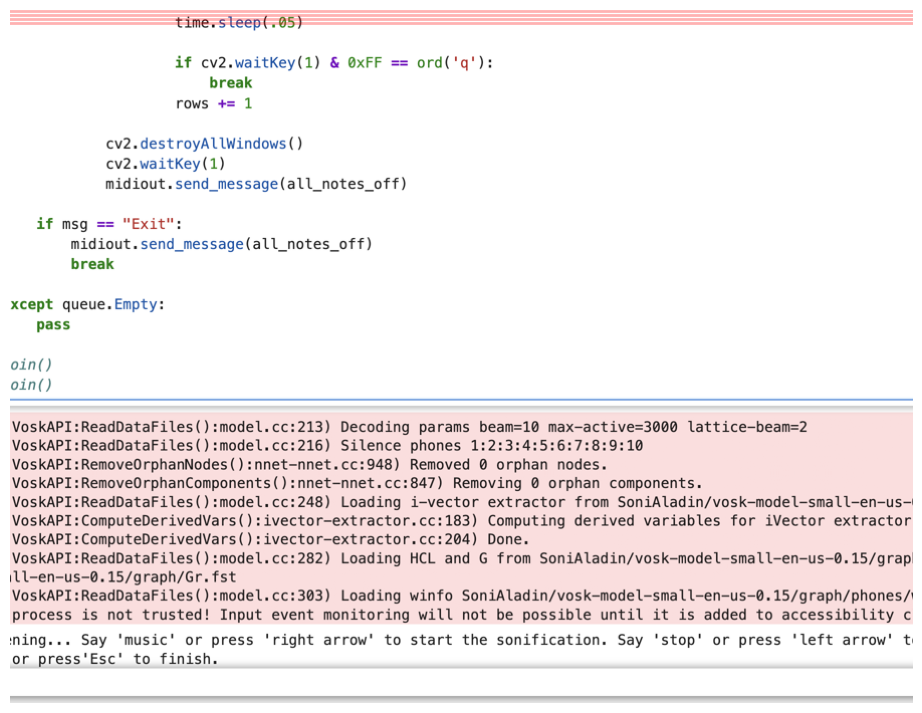

In [1]:
import time
import json
import queue
import threading
import numpy as np
import sounddevice as sd
from PIL import ImageGrab
from pynput import keyboard
from IPython.display import Audio
from vosk import Model, KaldiRecognizer

import cv2
import rtmidi
import matplotlib.pyplot as plt
from matplotlib.image import imread

#Load the speech recognition model 
model_path = "SoniAladin/vosk-model-small-en-us-0.15"     #Remember to include the model in the software pack
model = Model(model_path)
rec = KaldiRecognizer(model, 16000)  #16kHz recording audio sample rate

q = queue.Queue()
ctrl = queue.Queue()


#Normalization of bright levels, fits them to match the 128 values of velocity in MIDI
def scaled_brights(brights, v_min, v_max, midi_min=0, midi_max=127):
    #Normalizes to 0-1
    normalized_brights = (brights - v_min) / (v_max - v_min)
    #Scales to MIDI range
    velocity_scaled = normalized_brights * (midi_max - midi_min) + midi_min
    #Rounds and converts to integers within MIDI range
    velocity_scaled = np.clip(np.round(velocity_scaled), midi_min, midi_max).astype(int)
    return velocity_scaled

def callback(indata, frames, time, status):
    if status:
        print(status)
    q.put(bytes(indata))


#Keyboard control

def on_press(key):
    global running
    try:
        if key == keyboard.Key.left:
            print("Stopping sonification")
            ctrl.put("Stop")
        elif key == keyboard.Key.right:
            print("Starting sonification")
            ctrl.put("Sonification")
        elif key == keyboard.Key.esc:
            running = False
            return False
    except Exception as e:
        print("error:", e)


#Continuous listening for sonification control
def listening():
    print("Listening... Say 'music' or press 'right arrow' to start the sonification. Say 'stop' or press 'left arrow' to stop the sonification. Say 'exit' or press'Esc' to finish.")
    with sd.RawInputStream(samplerate=16000, blocksize=8000, dtype='int16',
                           channels=1, callback=callback):
        while True:
            data = q.get()                  #gets speech

            if rec.AcceptWaveform(data):
                result = json.loads(rec.Result())
                text = result.get('text', '').lower()
                if 'music' in text:
                    print("Starting sonification")
                    ctrl.put("Sonification")

                if 'stop' in text:
                    print("Stopping sonification")
                    ctrl.put("Stop")
                    
                if 'exit' in text:
                    print("Sonification module disconnected.")
                    ctrl.put("Exit")
    
t1 = threading.Thread(target=listening)
t1.start()

t2 = keyboard.Listener(on_press=on_press)
t2.start()


running = True

while running:
    try:
        msg = ctrl.get_nowait()
        if msg == "Sonification":
            print("Displaying Sonification")
    
            # Sonification parameters
            high_threshold = 65   #Bright levels
            low_threshold = 15
            resolution = 4         #Pixels
        
            rows = 0
            chords = []
            amplitudes = []
        
            midiout = rtmidi.MidiOut()
            available_ports = midiout.get_ports()
        
            if available_ports:
                midiout.open_port(0)  # Open first available port
            else:
                midiout.open_virtual_port("Virtual Output")
    
            #IMAGE CAPTURE
            bbox = (350, 250, 1249, 940)                   #Size of the screen capture
            screenshot = ImageGrab.grab(bbox=bbox)
            screenshot.save('SoniAladin/region_screenshot.png')
    
            Aladin_img = imread("SoniAladin/region_screenshot.png")
            
            #Pre-processing: Monochrome, perceived luminance = 0.299R+0.587G+0.114B (0-255)
            brights = 0.299*Aladin_img[ :, :,0] + 0.587*Aladin_img[ :, :,1] + 0.114*Aladin_img[ :, :,2] 
            v_min = np.min(brights)
            v_max = np.max(brights)
            normalized_brights = scaled_brights(brights, v_min, v_max)

            dims = np.shape(normalized_brights)
            x_dim = dims[1]
            y_dim = dims[0]
    
            # Creates a single persistent window before the loop
            window_name = 'SoniAladin'
            cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
            cv2.setWindowProperty(window_name, cv2.WND_PROP_VISIBLE, 1)
            
            # Starting with the image
            plt.figure(figsize=(12, 9))
            plt.imshow(Aladin_img)
            plt.axis("off") 
            plt.savefig('Sonialadin/image_aladin.png')
            img = cv2.imread("SoniAladin/image_aladin.png")
            cv2.imshow(window_name, img)
            cv2.waitKey(1)
          
            all_notes_off = [0xB0, 123, 0]
            midiout.send_message(all_notes_off)
    
            with midiout:
                for y in range(y_dim):
                    try:
                        msg2 = ctrl.get_nowait()
                        if msg2 == "Stop":
                            print("Sonification stopped")
                            cv2.destroyAllWindows()
                            break
                            
                        if msg2 == "Exit":
                            break
                            running = False

                    except queue.Empty:
                        pass
                        
                    if (y % resolution == 0):
                        blocks = 0
                        
                        #Draws the red exploration line in the image
                        plt.axhline(y=y, color='red', linewidth=2, alpha = 0.3)
                        plt.savefig('SoniAladin/image_aladin.png')

                        for x in range(x_dim):
                            if (x % resolution == 0):
                                blocks += 1
                                note = x/10
                                amplitude = int(normalized_brights[y][x])
                    
                                if normalized_brights[y][x] >= high_threshold: #Stars and Galaxies
                                    #Sound
                                    chords.append(x)
                                    amplitudes.append(amplitude)
                                    print ("_________Note:", x)
                    
                                    #note on: channel (ch1=0x90)/ note / velocity
                                    note_on = [0x90, note, amplitude] #Channel 1
                                    #note_off = [0x80, note, amplitude]  # Note off on same channel/note
                        
                                    midiout.send_message(note_on)
                                   # midiout.send_message(note_off)
            
                                if low_threshold < normalized_brights[y][x] < high_threshold:    #Faint objects
                    
                                    #note on: channel (ch1=0x90)/ note / velocity
                                    note_on = [0x91, note, amplitude] #Channel 2
                                    #note_off = [0x81, note, amplitude]  # Note off on same channel/note
                        
                                    midiout.send_message(note_on)
                                    #midiout.send_message(note_off)
                                '''           
                                if  normalized_brights[y][x] < low_threshold:    #Background noise
                    
                                    #note on: channel (ch1=0x90)/ note / velocity
                                    note_on = [0x92, note, amplitude] #Channel 3 
                                    #note_off = [0x81, note, amplitude]  # Note off on same channel/note
                        
                                    midiout.send_message(note_on)
                                    #midiout.send_message(note_off)
                                '''
                        img = cv2.imread("SoniAladin/image_aladin.png")
                        cv2.imshow(window_name, img)
                                
                        time.sleep(.05) 
                
                        if cv2.waitKey(1) & 0xFF == ord('q'):
                            break
                        rows += 1
            
                cv2.destroyAllWindows()
                cv2.waitKey(1)
                midiout.send_message(all_notes_off)

        if msg == "Exit":
            midiout.send_message(all_notes_off)
            break

    except queue.Empty:
        pass
